In [1]:
# install livelossplot if its not done yet
#pip install livelossplot

In [2]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from livelossplot import PlotLossesKerasTF

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
# Normalize the input data
# The pixel values range from 0 to 255, so we scale them to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape the data from (num_samples, 28, 28) to (num_samples, 784)
# This flattens the 28x28 images into 1D vectors of size 784
x_train = x_train.reshape((x_train.shape[0], 28 * 28))
x_test = x_test.reshape((x_test.shape[0], 28 * 28))

In [4]:
# One-hot encode the labels
# Convert the class labels into a binary matrix representation
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

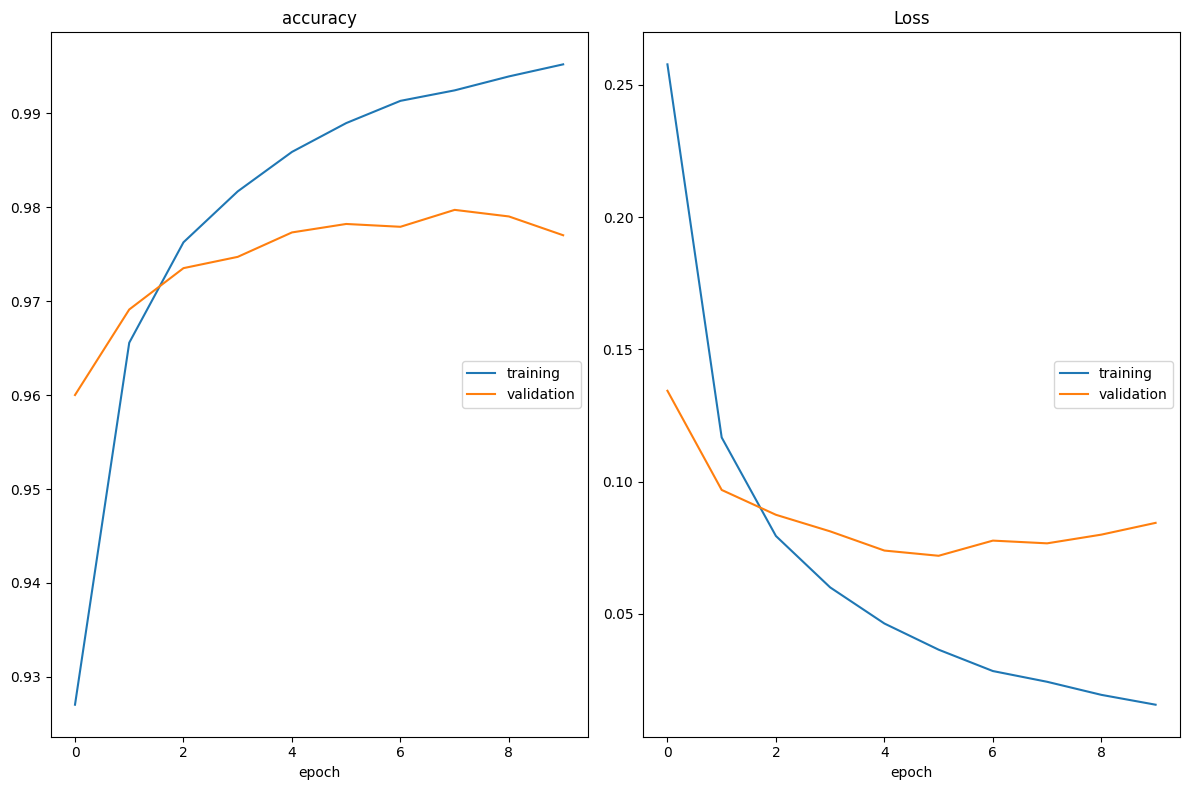

accuracy
	training         	 (min:    0.927, max:    0.995, cur:    0.995)
	validation       	 (min:    0.960, max:    0.980, cur:    0.977)
Loss
	training         	 (min:    0.016, max:    0.258, cur:    0.016)
	validation       	 (min:    0.072, max:    0.134, cur:    0.084)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 0.9770 - val_loss: 0.0844
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - accuracy: 0.9770 - loss: 0.0844
Test accuracy: 0.9769999980926514


In [5]:
# Build the neural network model
model = models.Sequential()
# Input layer and first hidden layer with 128 neurons and ReLU activation function
model.add(layers.Dense(128, activation='relu', input_shape=(784,)))
# Output layer with 10 neurons for the 10 classes, using softmax activation
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
# Specifying the optimizer, loss function, and evaluation metrics
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
# Fit the model on the training data for 10 epochs with a batch size of 32
model.fit(x_train, y_train,
          epochs=10,
          batch_size=32,
          validation_data=(x_test, y_test),callbacks=[PlotLossesKerasTF()])

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)